# 03 - Modeling (Extended Preprocessing)

Modelowanie z użyciem różnych wersji danych z rozszerzonego preprocessingu.

**Dostępne wersje:**
- `ddos_standard_scaled.csv` — StandardScaler
- `ddos_minmax_scaled.csv` — MinMaxScaler
- `ddos_smote.csv` — SMOTE oversampling
- `ddos_undersampled.csv` — Random undersampling
- `ddos_variance_threshold.csv` — VarianceThreshold feature selection
- `ddos_kbest_30.csv` — SelectKBest (30 cech)

**Modele:**
- Random Forest
- Linear SVM
- Logistic Regression

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib


sns.set_style("whitegrid")
%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [3]:
# Configuration
DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
FIGURES_DIR = "../reports/figures"
TEST_SIZE = 0.2
RANDOM_STATE = 42

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Wybierz wersję danych do użycia
# Możesz zmienić tę zmienną, aby przetestować różne wersje
DATA_VERSION = "ddos_smote.csv"  # zmień na inną wersję jeśli chcesz

DATA_PATH = os.path.join(DATA_DIR, DATA_VERSION)
print(f"Używana wersja danych: {DATA_VERSION}")

Używana wersja danych: ddos_smote.csv


## Wczytanie danych

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Kształt: {df.shape}")
print(f"\nRozkład targetu:")
print(df["target"].value_counts())
print(f"\nKlasa DDoS (1): {100 * df['target'].sum() / len(df):.2f}%")
df.head()

Kształt: (30960, 82)

Rozkład targetu:
target
1    15480
0    15480
Name: count, dtype: int64

Klasa DDoS (1): 50.00%


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Inbound,target
0,1.519646,-1.429176,-1.751494,0.001810,-0.012242,0.687419,-0.133301,0.239993,-0.039066,-0.928272,...,-0.036403,-0.049625,-0.049211,-0.025417,-0.221444,-0.170882,-0.232745,-0.200059,0.343682,1
1,1.519687,-1.429176,-1.751494,0.349482,-0.020000,0.065928,-0.258859,-0.032872,-0.964704,-0.928272,...,-0.036403,-0.049625,-0.049211,-0.025417,-0.221444,-0.170882,-0.232745,-0.200059,0.343682,1
2,-0.973092,1.011700,-1.751494,-0.242708,-0.023325,-0.111641,-0.258859,-0.032872,-0.964704,-0.928272,...,-0.036403,-0.049625,-0.049211,-0.025417,-0.221444,-0.170882,-0.232745,-0.200059,0.343682,0
3,-0.973092,1.012039,-1.751494,-0.242708,-0.023325,-0.111641,-0.258859,-0.032872,-0.964704,-0.928272,...,-0.036403,-0.049625,-0.049211,-0.025417,-0.221444,-0.170882,-0.232745,-0.200059,0.343682,0
4,-0.991426,-1.433052,-3.014893,5.111870,0.032091,-0.111641,-0.258859,-0.032872,-0.964704,-0.928272,...,-0.036392,-0.049616,-0.049195,-0.025408,1.273832,-0.002008,1.099290,1.359396,-2.909667,0


In [5]:
# Rozdziel cechy od targetu
X = df.drop(columns=["target"])
y = df["target"]

# Podział train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,} próbek")
print(f"Test: {len(X_test):,} próbek")
print(f"\nRozkład w zbiorze treningowym:")
print(y_train.value_counts())
print(f"\nRozkład w zbiorze testowym:")
print(y_test.value_counts())

Train: 24,768 próbek
Test: 6,192 próbek

Rozkład w zbiorze treningowym:
target
0    12384
1    12384
Name: count, dtype: int64

Rozkład w zbiorze testowym:
target
1    3096
0    3096
Name: count, dtype: int64


## Modelowanie

Trenowanie trzech modeli:
1. Random Forest
2. Linear SVM
3. Logistic Regression

In [6]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("Random Forest wytrenowany")

Random Forest wytrenowany


In [7]:
# Linear SVM
svm_base = LinearSVC(
    class_weight="balanced",
    max_iter=10000,
    random_state=RANDOM_STATE
)
svm = CalibratedClassifierCV(svm_base, cv=3)
svm.fit(X_train, y_train)
print("Linear SVM wytrenowany")

Linear SVM wytrenowany


In [8]:
# Logistic Regression
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr.fit(X_train, y_train)
print("Logistic Regression wytrenowana")

/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression wytrenowana


## Ewaluacja

In [9]:
# Predykcje
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

In [10]:
# Funkcja do obliczenia metryki
def compute_metrics(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

# Porównanie modeli
results = pd.DataFrame([
    compute_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf),
    compute_metrics("Linear SVM", y_test, y_pred_svm, y_proba_svm),
    compute_metrics("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
])

print("=== Wyniki na zbiorze testowym ===")
print(results.to_string(index=False))

=== Wyniki na zbiorze testowym ===
              Model  Accuracy  Precision  Recall       F1  ROC-AUC
      Random Forest  1.000000   1.000000 1.00000 1.000000 1.000000
         Linear SVM  0.991925   0.996738 0.98708 0.991886 0.999372
Logistic Regression  0.991279   0.995440 0.98708 0.991242 0.998954


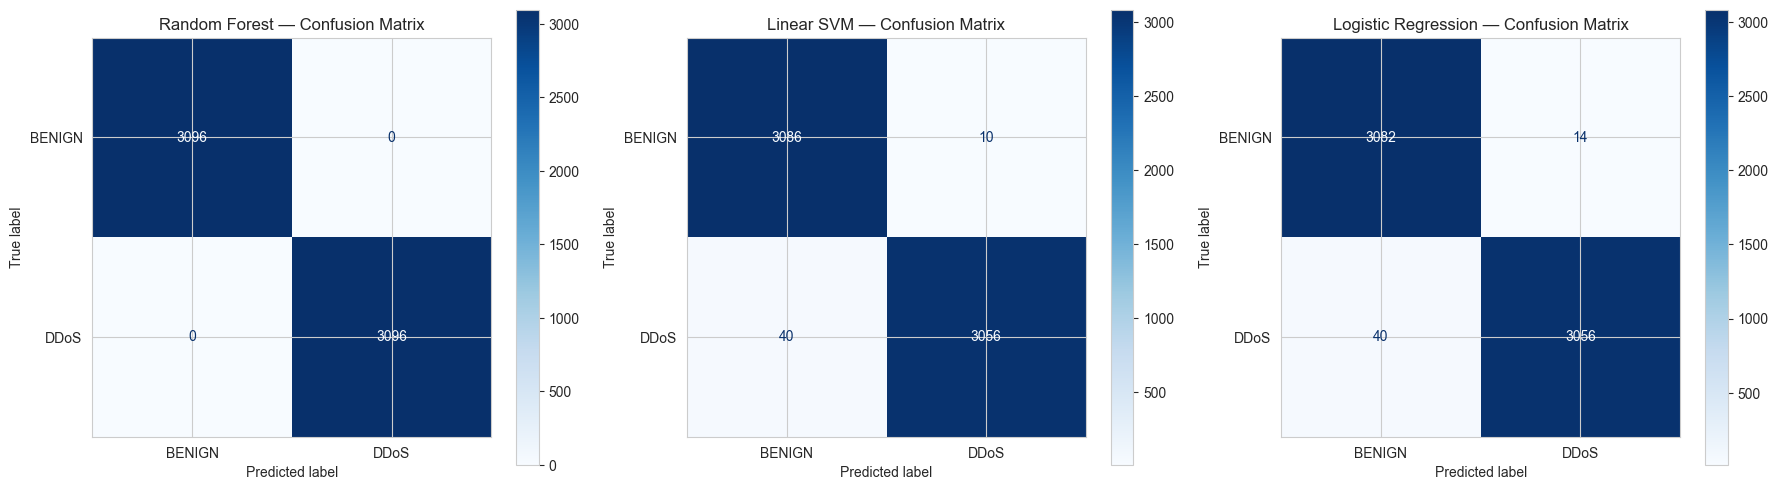

In [11]:
# Macierze pomyłek
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ("Random Forest", y_pred_rf),
    ("Linear SVM", y_pred_svm),
    ("Logistic Regression", y_pred_lr)
]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["BENIGN", "DDoS"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/confusion_matrices_extended.png", dpi=150)
plt.show()

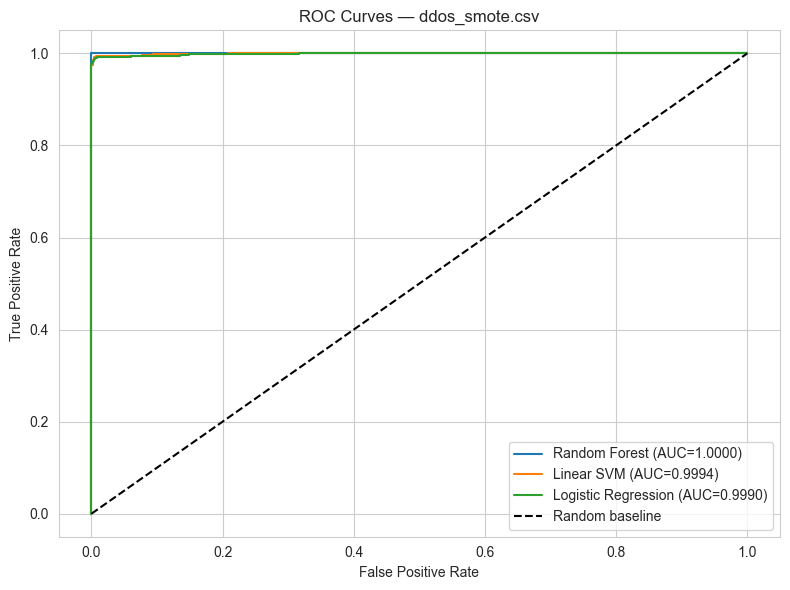

In [12]:
# Krzywe ROC
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in [
    ("Random Forest", y_proba_rf),
    ("Linear SVM", y_proba_svm),
    ("Logistic Regression", y_proba_lr)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves — {DATA_VERSION}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/roc_curves_extended.png", dpi=150)
plt.show()

## Cross-Validation (5-fold)

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1"]

models_cv = [
    ("Random Forest", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ("Linear SVM", CalibratedClassifierCV(LinearSVC(class_weight="balanced", max_iter=10000, random_state=RANDOM_STATE), cv=3)),
    ("Logistic Regression", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
]

print("=== Cross-Validation (5-fold) ===")
for name, model in models_cv:
    cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)
    print(f"\n{name}:")
    for metric in scoring:
        scores = cv_results[f"test_{metric}"]
        print(f"  {metric:12s}: {scores.mean():.4f} ± {scores.std():.4f}")

=== Cross-Validation (5-fold) ===

Random Forest:
  accuracy    : 0.9996 ± 0.0002
  precision   : 0.9999 ± 0.0002
  recall      : 0.9992 ± 0.0004
  f1          : 0.9996 ± 0.0002

Linear SVM:
  accuracy    : 0.9927 ± 0.0009
  precision   : 0.9970 ± 0.0010
  recall      : 0.9883 ± 0.0014
  f1          : 0.9926 ± 0.0009


/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/konrad.springer.ext/Library/Caches/pypoetry/virtualenvs/msi-ddos-detection-N_ejoZt7-py3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.wa


Logistic Regression:
  accuracy    : 0.9919 ± 0.0011
  precision   : 0.9969 ± 0.0014
  recall      : 0.9869 ± 0.0021
  f1          : 0.9919 ± 0.0011


## Zapis modeli

In [14]:
version_suffix = DATA_VERSION.replace(".csv", "")

joblib.dump(rf, f"{MODELS_DIR}/rf_{version_suffix}.joblib")
joblib.dump(svm, f"{MODELS_DIR}/svm_{version_suffix}.joblib")
joblib.dump(lr, f"{MODELS_DIR}/lr_{version_suffix}.joblib")

print(f"Modele zapisane dla wersji: {DATA_VERSION}")

Modele zapisane dla wersji: ddos_smote.csv


## Podsumowanie

Notebook ten pozwala na:
1. Wczytanie dowolnej wersji danych z rozszerzonego preprocessingu
2. Trening trzech modeli (Random Forest, SVM, Logistic Regression)
3. Ewaluację z użyciem różnych metryk
4. Cross-validation dla oceny stabilności
5. Zapis modeli

**Aby przetestować inne wersje danych:**
- Zmień wartość zmiennej `DATA_VERSION` w komórce konfiguracji
- Dostępne wersje:
  - `ddos_standard_scaled.csv`
  - `ddos_minmax_scaled.csv`
  - `ddos_smote.csv`
  - `ddos_undersampled.csv`
  - `ddos_variance_threshold.csv`
  - `ddos_kbest_30.csv`